In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from types import SimpleNamespace

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

from sklearn.manifold import TSNE

In [9]:
clust = 'gspy'
run = 'O3a'

arq_name = f'{clust}{run}'

In [10]:
base_data = '/home/esanches/Projetos/tSNE/Virgo/'
repository = f'/home/esanches/Projetos/tSNE/Virgo/zrepository/{clust}/{run}/'

filterr = True
dt = 2

## Filters application

* To see the lenght, in CMD use: **wc -l arquivename.csv**
* To see the columns, in CMD use: **head -n 1 arquivename.csv**

### Triggers

* COLUMNS: time, frequency, snr
* unclustered **70% randomly**

In [4]:
tperc, trigg_size = 0.7, 359385802
trigcols = ['time', 'frequency', 'snr']
ntrig = int(trigg_size*tperc)

In [5]:
""" Performs a random and filtered read of a large CSV file to save memory """

np.random.seed(42)
skip_logic = lambda i: i > 0 and np.random.random() > tperc
trigg = pd.read_csv(f'{base_data}triggers_total.csv', skiprows=skip_logic, usecols=trigcols)
trigg = trigg.sort_values('time').reset_index(drop=True)
unclustered = trigg.copy()

In [ ]:
unclustered.to_csv(f'{repository}unclustered_{arq_name}.csv')

### Gravity Spy clustering

* COLUMNS: GPStime, peakFreq, snr, amplitude, centralFreq, duration, bandwidth, chisq, chisqDof, confidence, id, ifo, label, imgUrl, Q-value
* clustered **top10 glitches**, **confidence > 90%** and cut **1000 glitches per label**
* clustered **remove None_of_the_Above and No_Glitch**

In [11]:
gperc, glit_size = 1.0, 187770
glitcols = ['GPStime', 'centralFreq', 'snr', 'label', 'confidence']
nglit = int(glit_size*gperc)

In [12]:
""" Apply filters to the glitches """

glit = pd.read_csv(f'{base_data}{arq_name}.csv', usecols=glitcols)

glit = glit[glit['confidence'] >= 0.9]
glit = glit.drop(glit[glit['label'].isin(['None_of_the_Above', 'No_Glitch'])].index)

top10 = glit['label'].value_counts().head(10).index
glit = glit[glit['label'].isin(top10)].copy()

glit = glit.sort_values(by=[glitcols[0]]).reset_index(drop=True)

if filterr == True:
    limited_glit = glit.groupby('label', group_keys=False).apply(lambda x: x.sample(n=min(len(x), 1000), random_state=42))
    limited_glit = limited_glit.sort_values(by=['GPStime']).reset_index(drop=True)
            
    clustered = limited_glit.copy()
else:
    clustered = glit.copy()

In [ ]:
clustered.to_csv(f'{repository}clustered_{arq_name}.csv')

### Detchar clustering

* COLUMNS: Unnamed: 0, cluster, tstart, tend, fmin, fmax, time, frequency, q, snr, phase

In [6]:
gperc, glit_size = 1.0, 2954296
glitcols = ['time', 'frequency', 'snr', 'q']
nglit = int(glit_size*gperc)

In [7]:
glit = pd.read_csv(f'{base_data}{arq_name}.csv', usecols=glitcols)

In [13]:
glit

,time,frequency,q,snr
0,1.250941e+09,19.494597,18.211603,5.029885
1,1.250941e+09,40.434841,35.992242,5.257632
2,1.250941e+09,19.494597,18.211603,6.175278
3,1.250941e+09,1079.892919,4.662584,5.127510
4,1.250941e+09,1848.646754,35.992242,5.055540
...,...,...,...,...
2954290,1.245600e+09,808.628577,18.211603,5.077682
2954291,1.245600e+09,44.399906,71.132756,5.766186
2954292,1.245600e+09,1504.486253,18.211603,5.032673
2954293,1.245600e+09,20.626565,18.211603,5.547209


In [14]:
glit = glit[(glit['frequency'] >= 3) & (glit['frequency'] <= 8192)]
glit = glit[(glit['snr'] >= 6.5) & (glit['snr'] <= 10)]

In [15]:
clustered = glit.copy()

In [ ]:
clustered.to_csv(f'{repository}clustered_{arq_name}.csv')

In [18]:
clustered

,time,frequency,q,snr
8,1.250941e+09,29.602930,71.132756,7.034017
11,1.250941e+09,25.851009,18.211603,8.062396
20,1.250941e+09,39.297683,35.992242,7.732386
22,1.250941e+09,23.144554,71.132756,8.144450
25,1.250941e+09,25.851009,18.211603,6.760834
...,...,...,...,...
2954125,1.245598e+09,47.733038,71.132756,6.685572
2954127,1.245598e+09,47.733038,71.132756,6.825029
2954129,1.245598e+09,47.733038,71.132756,6.597985
2954239,1.245600e+09,38.192506,35.992242,8.559703


### vectorization

In [17]:
def glitch_to_glitchgram(unclustered, clustered, savepath, arq_name, deltat, 
                         fmin=3, fmax=8192, tbins=41, fbins=30):
    """
    This function create one glitchgram from unclustered Omicron data, for each glitch.

    Parameters:
        df_triggers (dataFrame): A dataFrame of GPStimes of all triggers inside of some window.
        tmin, tmax (numbers): limits of GPStimes that contain all triggers of some glitch.
        fmin, fmax (numbers): frequency range for the glitchgram.
        n_time_bins (int): number of time bins.
        n_freq_bins (int): number of frequency bins.
        norm (boolean): True if you need normalize SNR values.

    Returns:
        array for some glitch: each entry is a SNR value from flattened (binsf × binst) matrix.
    """

    times_all = unclustered['time'].values
    freqs_all = unclustered['frequency'].values
    snrs_all  = unclustered['snr'].values

    vecs = []
    labs = []
    GPSs = []

    time_edges = np.linspace(-deltat/2, deltat/2, tbins+1)
    freq_edges = np.logspace(np.log10(fmin), np.log10(fmax), fbins+1)
    
    for i, row in enumerate(clustered.itertuples(index=False)):

        #t_center = getattr(row, 'GPStime')
        t_center = row.GPStime
    
        tmin = t_center - deltat/2
        tmax = t_center + deltat/2
    
        i0 = np.searchsorted(times_all, tmin, side="left")
        i1 = np.searchsorted(times_all, tmax, side="right")
    
        times = times_all[i0:i1] - t_center
        freqs = freqs_all[i0:i1]
        snrs  = snrs_all[i0:i1]

        if len(times) < 10: # Equivalente ao tcut
            continue
    
        df_triggers = pd.DataFrame({'time': times,'frequency': freqs,'snr': snrs})
        
        t_idx = np.digitize(df_triggers['time'].values, time_edges) - 1
        f_idx = np.digitize(df_triggers['frequency'].values, freq_edges) - 1
            
        # initial empty matrix
        A = np.zeros((fbins, tbins), dtype=float)
    
        for ti, fi, si in zip(t_idx, f_idx, snrs):
            if 0 <= ti < tbins and 0 <= fi < fbins:
                if si > A[fi, ti]:
                    A[fi, ti] = si
                    
        '''# normalização do SNR 
        if len(snrs) > 0:
            snr_min = snrs.min()
            snr_max = snrs.max()
            if snr_max > snr_min:
                norm_snrs = (snrs - snr_min) / (snr_max - snr_min)
            else:
                norm_snrs = np.zeros_like(snrs)
        else:
            norm_snrs = snrs'''
        
        vecs.append(A.flatten(order="C"))
        labs.append(row.label)
        GPSs.append(row.GPStime)

    vecs_final = np.array(vecs).astype('float32')
    labs_final = np.array(labs)
    GPSs_final = np.array(GPSs).astype('float32')
    
    return vecs_final, labs_final, GPSs_final

In [18]:
vecs, labs, GPSs = glitch_to_glitchgram(unclustered, clustered, repository, arq_name, dt, fmin=3, fmax=8192, tbins=41, fbins=30)

In [19]:
np.save(f'{repository}vecs_{arq_name}_dt{dt}.npy', vecs)
np.save(f'{repository}labs_{arq_name}_dt{dt}.npy', labs)
np.save(f'{repository}GPSs_{arq_name}_dt{dt}.npy', GPSs)

### tSNE for detchar clustering

In [36]:
final_vecs = np.load(f'{repository}vecs_{arq_name}_dt{dt}.npy')
final_GPSs = np.load(f'{repository}GPSs_{arq_name}_dt{dt}.npy')

In [37]:
final_vecs

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(156528, 1230), dtype=float32)

In [39]:
idx = np.random.choice(len(final_vecs), size=10000, replace=False)
final_vecs_sub = final_vecs[idx]

# Teste o t-SNE aqui (deve rodar em poucos minutos)
tsne = TSNE(n_components=2, n_jobs=-1, verbose=0, perplexity=100, learning_rate=200, max_iter=1000, metric="euclidean", random_state=0)
proj_sub = tsne.fit_transform(final_vecs_sub)

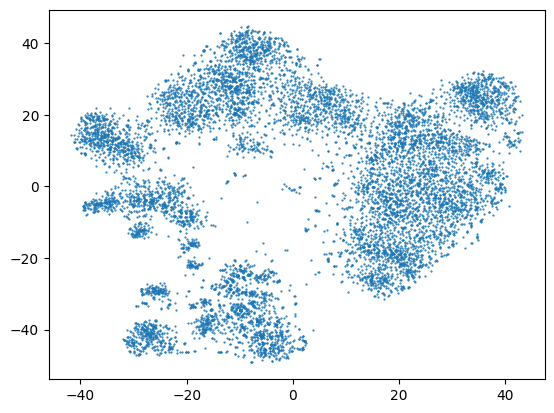

In [42]:
plt.scatter(proj_sub[:, 0], proj_sub[:, 1], s=0.3)